Analyzing pervoskite candidate stability with expanded dataset.

In the previous notebook, we established the following analysis pipeline:

1) data acquisition via Materials Project API

2) Data pre-processing and cleaning

3) Model Training and Testing

Here, we will apply the same workflow, but increase the size of our dataset. The Perovskite family ABX3, includes several distinct kinds of AB pairings. In the previous notebook, we focused on the paring: "Pb" and "I"


In [10]:
from mp_api.client import MPRester
import pandas as pd
import numpy as np
from dotenv import load_dotenv
import os
load_dotenv()
MY_API_KEY = os.getenv("MP_API_KEY")



Before we get started, we will define a series of helper functions to simplify the code

In [11]:
def query_materials(API_KEY, Metal_Halide_Pairings):
    data = []
    with MPRester(API_KEY) as mpr: 
        for pairing in Metal_Halide_Pairings:
            docs = mpr.materials.summary.search(
            elements=pairing,
            band_gap=(0.5, 3.0),
            fields=[
                "formula_pretty",
            "band_gap",
            "energy_above_hull",
            "formation_energy_per_atom",
            "volume",
            "density",  
            "nsites"
        ])
            for doc in docs:
                data.append({
            "formula": doc.formula_pretty,
            "band_gap": getattr(doc, "band_gap", None),
            "energy_above_hull": getattr(doc, "energy_above_hull", None),
            "formation_energy": getattr(doc, "formation_energy_per_atom", None),
            "volume": getattr(doc, "volume", None),
            "density": getattr(doc, "density", None),
            "nsites": getattr(doc, "nsites", None)
        })
            # Converting the list of dictionaries into a pandas DataFrame makes data manipulation and usage much more convenient
        df = pd.DataFrame(data)

            # Drop rows where key columns are missing
        df = df.dropna(subset=["band_gap", "energy_above_hull"])
    return df
    

Before we start our query, we need to consider two changes to the features we search across. First and foremost, we want to include different X site ions. In the first iteration of the notebook, we just did a Pb, I, pairing. We will first expand our lead pairings to include Cl and Br too. 

We also want to take into account differnt B site metals. Looking at the periodic table, the next closest candidates to Pb that aren't radioactive would be Sn and Ge. However, their smaller atomic radii relative to Pb may affect the Goldschmidt tolerance factor and structural stability. 

Below, we will run the query with multiple different pairings to confirm that there exists recorded structures of these different pairings. 

STEP 1: Query Materials Project for Data

In [12]:
Pb_family = [["Pb", "I"], ["Pb", "Br"], ["Pb", "Cl"]]
Sn_family = [["Sn", "I"], ["Sn", "Br"], ["Sn", "Cl"]]
Ge_family = [["Ge", "I"], ["Ge", "Br"], ["Ge", "Cl"]]

df_Pb = query_materials(MY_API_KEY, Pb_family)
df_Sn = query_materials(MY_API_KEY, Sn_family) 
df_Ge = query_materials(MY_API_KEY, Ge_family)

print(f"Found {len(df_Pb)} materials after cleaning")
print(f"Found {len(df_Sn)} materials after cleaning")
print(f"Found {len(df_Ge)} materials after cleaning")


Retrieving SummaryDoc documents:   0%|          | 0/89 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/62 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/79 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/38 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/50 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/77 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/19 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/25 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/16 [00:00<?, ?it/s]

Found 230 materials after cleaning
Found 165 materials after cleaning
Found 60 materials after cleaning


The above results tell us that there are still many candidates for testing for Ge and Sn. As expected, Ge has a lower number of available candidates, but this is still a usable number.

In [13]:
halide_family = Pb_family + Sn_family + Ge_family

df =  query_materials(MY_API_KEY, halide_family)


print(f"Found {len(df)} materials after cleaning")
print(df.head())
print("\nMissing values per column:")
print(df.isnull().sum())



Retrieving SummaryDoc documents:   0%|          | 0/89 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/62 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/79 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/38 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/50 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/77 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/19 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/25 [00:00<?, ?it/s]

Retrieving SummaryDoc documents:   0%|          | 0/16 [00:00<?, ?it/s]

Found 455 materials after cleaning
      formula  band_gap  energy_above_hull  formation_energy       volume  \
0    NaPb2IO6    2.6086           0.040496         -1.335463   142.155223   
1     HPb2IO2    2.3274           0.092941         -1.192513   317.570602   
2  H6PbC3S2IN    2.8510           0.145013         -0.269725   971.279590   
3  H8PbC5S2IN    2.9546           0.125306         -0.232263  1178.374986   
4   P3Pb5IO12    2.4246           0.033441         -2.200603   698.899020   

    density  nsites  
0  7.712966      10  
1  6.006011      12  
2  3.106902      56  
3  2.707639      72  
4  6.879847      42  

Missing values per column:
formula              0
band_gap             0
energy_above_hull    0
formation_energy     0
volume               0
density              0
nsites               0
dtype: int64


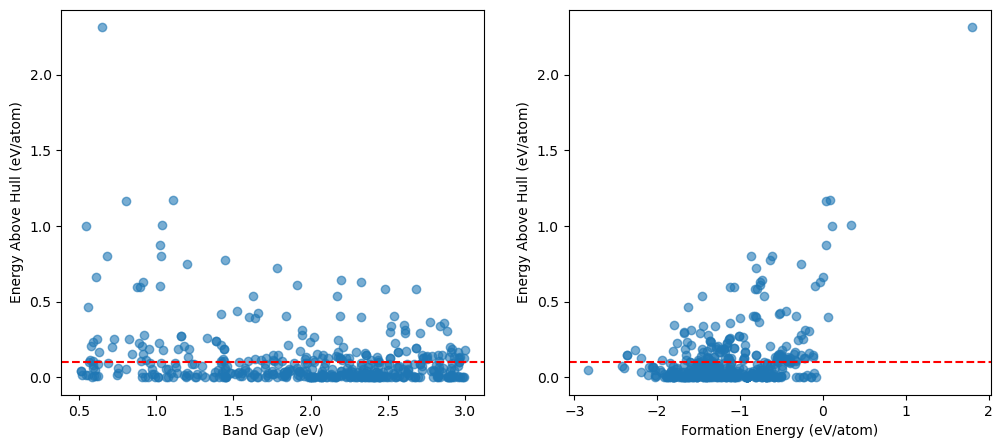

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# Plotting Band Gap vs Stability (energy above hull)
axes[0].scatter(df["band_gap"], df["energy_above_hull"], alpha = 0.6)
axes[0].axhline(y = 0.1, color = "r", linestyle = "--")
axes[0].set_xlabel("Band Gap (eV)")
axes[0].set_ylabel("Energy Above Hull (eV/atom)")

# Plotting Formation energy vs. Stability (energy above hull)
axes[1].scatter(df["formation_energy"], df["energy_above_hull"], alpha= 0.6)
axes[1].axhline(y = 0.1, color = "r", linestyle = "--")
axes[1].set_xlabel("Formation Energy (eV/atom)")
axes[1].set_ylabel("Energy Above Hull (eV/atom)")

plt.show()

STEP 2: Data Cleaning + Featurization

In [15]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

str_to_comp = StrToComposition()
df = str_to_comp.featurize_dataframe(df, "formula", ignore_errors=True)
ep_featurizer = ElementProperty.from_preset("magpie")
df = ep_featurizer.featurize_dataframe(df, col_id = "composition", ignore_errors=True)

print(f"dataframe now has {df.shape[1]} columns after featurization")
print(df.head())

StrToComposition:   0%|          | 0/455 [00:00<?, ?it/s]

ElementProperty:   0%|          | 0/455 [00:00<?, ?it/s]

dataframe now has 140 columns after featurization
      formula  band_gap  energy_above_hull  formation_energy       volume  \
0    NaPb2IO6    2.6086           0.040496         -1.335463   142.155223   
1     HPb2IO2    2.3274           0.092941         -1.192513   317.570602   
2  H6PbC3S2IN    2.8510           0.145013         -0.269725   971.279590   
3  H8PbC5S2IN    2.9546           0.125306         -0.232263  1178.374986   
4   P3Pb5IO12    2.4246           0.033441         -2.200603   698.899020   

    density  nsites          composition  MagpieData minimum Number  \
0  7.712966      10       (Na, Pb, I, O)                        8.0   
1  6.006011      12        (H, Pb, I, O)                        1.0   
2  3.106902      56  (H, Pb, C, S, I, N)                        1.0   
3  2.707639      72  (H, Pb, C, S, I, N)                        1.0   
4  6.879847      42        (P, Pb, I, O)                        8.0   

   MagpieData maximum Number  ...  MagpieData range GSmagmom

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Cleaning non-numeric features from the dataframe as the model cannot use them
exclude_cols = ["formula", "composition", "energy_above_hull", "band_gap",
"formation_energy", "volume", "density", "nsites"]
feature_cols = [col for col in df.columns if col not in exclude_cols]
df_clean = df.dropna(subset = feature_cols  + ["energy_above_hull"])

X = df_clean[feature_cols]
y = df_clean["energy_above_hull"]
print(f"Post cleaning and featurization, we are now training on {X.shape[0]} materials with {X.shape[1]} features")

Post cleaning and featurization, we are now training on 455 materials with 132 features


STEP 3: Training and Testing the Model

In [17]:
# split our data into the test and training sets using 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Display number of samples in training and testing sets
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# Train the model: Here we create 100 different trees for the random forest,
# and set a random state for reproducability
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train, y_train)

# Evaluate
# Using the trained model, we take our testing data, X_test, and predict the energy above hull values, y_pred
# We then compare these predicted values against the actual test values, y_test, and claculate r^2 values and mean absolute error.
y_pred = rf.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Finally, we print out our evaluation of the model's accuracy 
print(f"Mean Absolute Error: {mae:.4f} eV/atom")
print(f"R² Score: {r2:.4f}")

Training set: 364 samples
Testing set: 91 samples
Mean Absolute Error: 0.0548 eV/atom
R² Score: 0.5855


Plot Results:

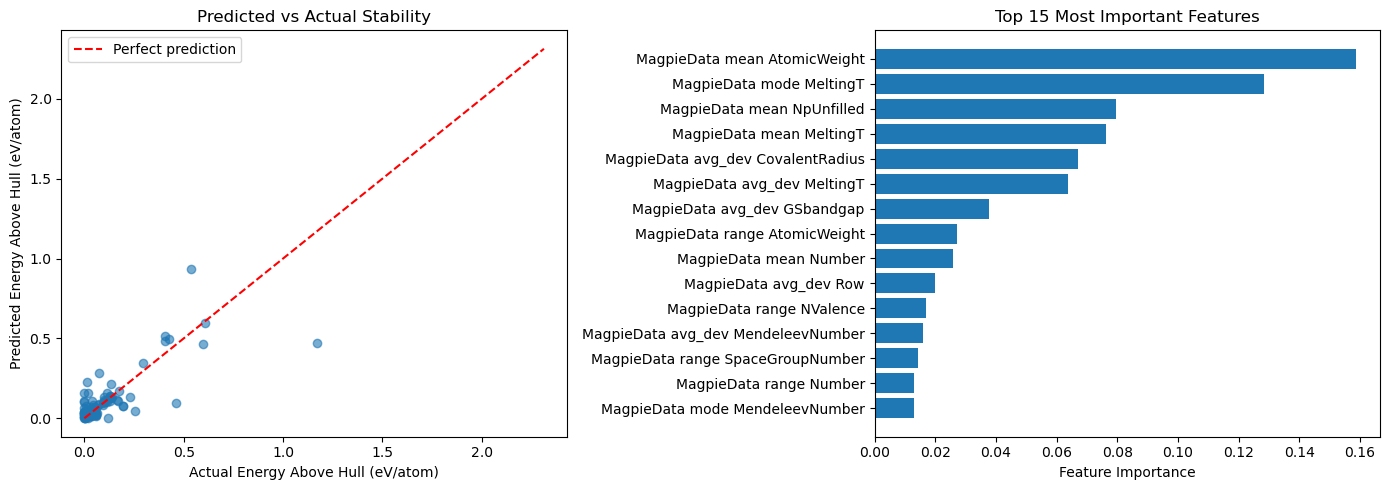

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual
axes[0].scatter(y_test, y_pred, alpha=0.6)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel("Actual Energy Above Hull (eV/atom)")
axes[0].set_ylabel("Predicted Energy Above Hull (eV/atom)")
axes[0].set_title("Predicted vs Actual Stability")
axes[0].legend()

# Top 15 most important features
importances = pd.Series(rf.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(15)

axes[1].barh(top_features.index[::-1], top_features.values[::-1])
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 15 Most Important Features")

plt.tight_layout()
plt.show()

Based on the results plotted below as well as our error, it is evident there is still a ways to go in terms of accuracy. Its much better than our single pairing model that had an r^2 value of 0.09. Now the r^2 is 0.5855. 

This value is substantially better, but there are other factors that we still have yet to include.
Currently, we are only training our model off predictions based on the individual components of the pervoskite structure. However, we fail to account for the assembly of the structure itself. To do this we must include the Goldschmidt Tolerance Factor, and we'll execute this in the next iteration 